# CPHASE Gate Optimization: Time-Optimal Parametrized CZ_φ

Train a neural network to generate time-optimal CPHASE (CZ_φ) gates across multiple angles.

**Approach:**
- **Time network**: Predicts optimal gate time for each angle
- **Control network**: Generates detuning pulse given (angle, time)
- **Rabi fixed at Ω_max** (time-optimal by definition)
- **Loss**: Infidelity + time penalty

This notebook reproduces the results from `CPHASE_results/cphase_optim.ipynb` using the qneural library.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys

# Setup path
import os
sys.path.insert(0, os.path.dirname(os.getcwd()))

# Imports
from qneural.gates.rydberg import CZPhiGate
from qneural.neural import TimeOptimalController, TimeOptimalTrainer
from qneural.core.gates import czphi_gate
from qneural.core.metrics import unitary_fidelity

print("✓ Imports successful")

✓ Imports successful


## 1. Configuration

**Hyperparameters from publication:**
- Time network: 3 layers × 45 units
- Control network: 10 layers × 300 units
- Time bounds: [3.0, 8.5] (normalized by Ω_max)
- Detuning range: [-2Ω_max, 2Ω_max]
- Time steps: 201
- Time penalty: 5e-3

In [23]:
# Physical parameters
gate = CZPhiGate()
rabi_max = gate.rabi_max  # Ω_max ≈ 25.13 MHz

# Time bounds in physical units (seconds)
TIME_BOUNDS_NORMALIZED = (3.0, 8.5)  # In units of 1/Ω_max
TIME_BOUNDS = (TIME_BOUNDS_NORMALIZED[0] / rabi_max, TIME_BOUNDS_NORMALIZED[1] / rabi_max)

# Detuning range
DETUNING_RANGE = (-2.0 * rabi_max, 2.0 * rabi_max)

# Training parameters
ANGLE_BATCH = 80  # Number of angles per batch
N_TIME_STEPS = 201  # From archival code
EPOCHS = 50
TIME_PENALTY = 5e-3  # Multiplier for time term in loss

# Angle range to optimize over
ANGLE_RANGE = (0.4 * np.pi, 0.6 * np.pi)  # Can be adjusted

print(f"Configuration:")
print(f"  Rabi max: {rabi_max:.2f} MHz")
print(f"  Time bounds: [{TIME_BOUNDS_NORMALIZED[0]:.1f}, {TIME_BOUNDS_NORMALIZED[1]:.1f}] / Ω_max")
print(f"  Time bounds (physical): [{TIME_BOUNDS[0]:.4f}, {TIME_BOUNDS[1]:.4f}] s")
print(f"  Detuning range: [{DETUNING_RANGE[0]:.1f}, {DETUNING_RANGE[1]:.1f}] MHz")
print(f"  Angle range: [{ANGLE_RANGE[0]/np.pi:.2f}π, {ANGLE_RANGE[1]/np.pi:.2f}π]")
print(f"  Time steps: {N_TIME_STEPS}")
print(f"  Angle batch size: {ANGLE_BATCH}")
print(f"  Time penalty: {TIME_PENALTY}")

Configuration:
  Rabi max: 25.13 MHz
  Time bounds: [3.0, 8.5] / Ω_max
  Time bounds (physical): [0.1194, 0.3382] s
  Detuning range: [-50.3, 50.3] MHz
  Angle range: [0.40π, 0.60π]
  Time steps: 201
  Angle batch size: 80
  Time penalty: 0.005


## 2. Create Controller

The `TimeOptimalController` contains:
- **Time predictor**: Maps angle → gate time
- **Control generator**: Maps (angle, time) → detuning pulse

In [24]:
controller = TimeOptimalController(
    time_bounds=TIME_BOUNDS,
    rabi_max=rabi_max,
    detuning_range=DETUNING_RANGE,
    n_time_steps=N_TIME_STEPS,
    # Network architecture from archival code
    time_hidden_layers=3,
    time_hidden_units=45,
    control_hidden_layers=10,
    control_hidden_units=300,
    # Output activations
    time_output_activation='tanh',  # From archival 'mode = tanh'
    # Weight initialization scales from archival code
    weight_scale_time=1.8,      # beta_time
    weight_scale_control=1.55   # beta_control
)

# Count parameters
time_params = sum(p.numel() for p in controller.time_predictor.parameters())
control_params = sum(p.numel() for p in controller.control_generator.parameters())
total_params = time_params + control_params

print(f"Controller created:")
print(f"  Time network: {time_params:,} parameters")
print(f"  Control network: {control_params:,} parameters")
print(f"  Total: {total_params:,} parameters")
print(f"\nArchitecture:")
print(f"  Time: 3 layers x 45 units")
print(f"  Control: 10 layers x 300 units")

Controller created:
  Time network: 4,276 parameters
  Control network: 813,901 parameters
  Total: 818,177 parameters

Architecture:
  Time: 3 layers x 45 units
  Control: 10 layers x 300 units


In [13]:
# Learning rates from archival code (after warmup)
TIME_LR = 1e-5
CONTROL_LR = 1e-4

trainer = TimeOptimalTrainer(
    controller=controller,
    nqubits=2,
    time_weight=TIME_PENALTY,
    time_lr=TIME_LR,
    control_lr=CONTROL_LR
)

print("✓ TimeOptimalTrainer created")
print(f"  Time optimizer: Adam(lr={TIME_LR}, amsgrad=True)")
print(f"  Control optimizer: Adam(lr={CONTROL_LR}, amsgrad=True)")
print(f"  Solver: RK4 with {N_TIME_STEPS} steps")
print(f"  Time penalty weight: {TIME_PENALTY}")

✓ TimeOptimalTrainer created
  Time optimizer: Adam(lr=1e-05, amsgrad=True)
  Control optimizer: Adam(lr=0.0001, amsgrad=True)
  Solver: RK4 with 201 steps
  Time penalty weight: 0.05


## 4. Visualize Initial Predictions

Check that the network initializes to reasonable values (not near zero).

Test prediction for angle = 0.5π:
  Predicted gate time: 3.02 (normalized)
  Predicted gate time: 0.1201 s (physical)
  Detuning normalized shape: torch.Size([1, 201, 1])
  Detuning scaled shape: torch.Size([1, 201, 1])
  Detuning range: [-40.11, -39.75] MHz


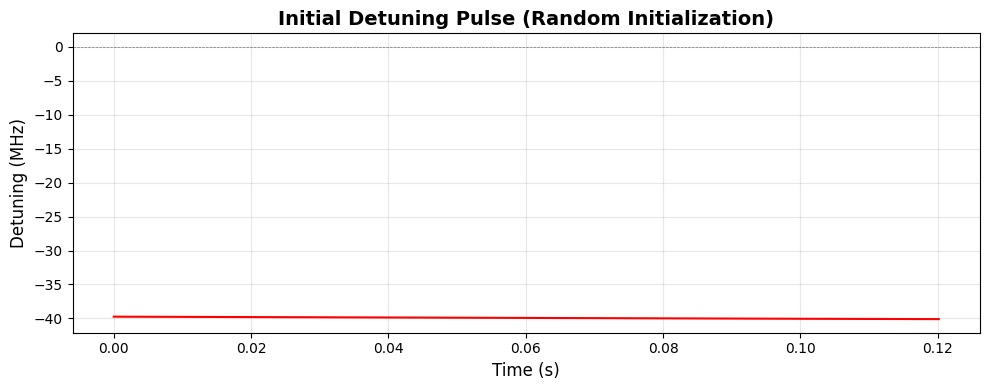


✓ Initial pulse varies with time (not constant)


In [19]:
# Test on single angle
test_angle = torch.tensor([[0.5 * np.pi]])
gate_time, detuning_normalized = controller(test_angle)

# Scale to physical units
detuning = controller.scale_detuning(detuning_normalized)

print(f"Test prediction for angle = 0.5π:")
print(f"  Predicted gate time: {gate_time.item() * rabi_max:.2f} (normalized)")
print(f"  Predicted gate time: {gate_time.item():.4f} s (physical)")
print(f"  Detuning normalized shape: {detuning_normalized.shape}")
print(f"  Detuning scaled shape: {detuning.shape}")
print(f"  Detuning range: [{detuning.min().item():.2f}, {detuning.max().item():.2f}] MHz")

# Plot initial detuning pulse
times = np.linspace(0, gate_time.item(), N_TIME_STEPS)
plt.figure(figsize=(10, 4))
plt.plot(times, detuning.squeeze().detach().numpy(), 'r-', linewidth=1.5)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Detuning (MHz)', fontsize=12)
plt.title('Initial Detuning Pulse (Random Initialization)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Initial pulse varies with time (not constant)")

## 5. Single Angle Optimization

First optimize for a single angle to verify the setup works. As NNs are randomly initialized, it's also nice to realize if we started off from a 'favorable region' before using more computational resources on the multi-angle optimization.  

In [15]:
# Single angle: CZ gate (π)
single_angle = torch.tensor([0.5 * np.pi]).reshape(1, 1)

print(f"Optimizing for single angle: {single_angle.item()/np.pi:.2f}π\n")

# Train for fewer epochs for single angle
history_single = trainer.train(
    angles=single_angle,
    epochs=200,
    print_every=20
)

final_infidelity = history_single['infidelity'][-1]
final_gate_time = history_single['mean_gate_time'][-1]

print(f"\n{'='*60}")
print(f"Single angle optimization complete!")
print(f"  Final infidelity: {final_infidelity:.6f}")
print(f"  Final fidelity: {(1 - final_infidelity)*100:.2f}%")
print(f"  Optimized gate time: {final_gate_time * rabi_max:.2f} (normalized)")
print(f"{'='*60}")


Optimizing for single angle: 0.50π

Epoch 0: Loss = 0.843901, Infidelity = 0.837830, Mean Time = 3.0520
Epoch 20: Loss = 0.328383, Infidelity = 0.322315, Mean Time = 3.0501
Epoch 40: Loss = 0.322218, Infidelity = 0.316160, Mean Time = 3.0450
Epoch 60: Loss = 0.321910, Infidelity = 0.315861, Mean Time = 3.0405
Epoch 80: Loss = 0.322116, Infidelity = 0.316075, Mean Time = 3.0366
Epoch 100: Loss = 0.322355, Infidelity = 0.316320, Mean Time = 3.0332
Epoch 120: Loss = 0.322568, Infidelity = 0.316540, Mean Time = 3.0302
Epoch 140: Loss = 0.322755, Infidelity = 0.316731, Mean Time = 3.0277
Epoch 160: Loss = 0.322916, Infidelity = 0.316897, Mean Time = 3.0255
Epoch 180: Loss = 0.323057, Infidelity = 0.317042, Mean Time = 3.0235

Single angle optimization complete!
  Final infidelity: 0.317165
  Final fidelity: 68.28%
  Optimized gate time: 3.02 (normalized)


## 6. Multi-Angle Optimization

Optimize over a range of angles. The network learns to predict optimal gate times AND pulses for each angle.

In [16]:
print("Starting multi-angle optimization...\n")
print(f"Angle range: [{ANGLE_RANGE[0]/np.pi:.2f}π, {ANGLE_RANGE[1]/np.pi:.2f}π]")
print(f"Batch size: {ANGLE_BATCH} angles per epoch\n")

# Sample angles uniformly from range
angle_samples = torch.rand(ANGLE_BATCH, 1) * (ANGLE_RANGE[1] - ANGLE_RANGE[0]) + ANGLE_RANGE[0]

# Train with angle resampling (archival pattern)
history = trainer.train(
    angles=angle_samples,
    epochs=EPOCHS,
    angle_range=ANGLE_RANGE,  # Enable resampling
    resample_every=250,  # Resample angles every 25 epochs (archival pattern)
    print_every=10
)

# Convert final time from seconds to normalized Rabi units for display
final_time_rabi_units = history['mean_gate_time'][-1] * rabi_max

print(f"\n{'='*60}")
print(f"Multi-angle optimization complete!")
print(f"  Final mean infidelity: {history['infidelity'][-1]:.6f}")
print(f"  Final mean fidelity: {(1 - history['infidelity'][-1])*100:.2f}%")
print(f"  Final mean gate time: {final_time_rabi_units:.2f} (Ω_max × T)")
print(f"{'='*60}")

Starting multi-angle optimization...

Angle range: [0.40π, 0.60π]
Batch size: 80 angles per epoch

Epoch 0: Loss = 0.316604, Infidelity = 0.310579, Mean Time = 3.0284
Epoch 10: Loss = 0.316647, Infidelity = 0.310625, Mean Time = 3.0274
Epoch 20: Loss = 0.316739, Infidelity = 0.310718, Mean Time = 3.0264


KeyboardInterrupt: 

## 7. Plot Training Progress

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss
axes[0].plot(history['epoch'], history['loss'], 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Total Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Infidelity
axes[1].plot(history['epoch'], history['infidelity'], 'r-', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Mean Infidelity', fontsize=12)
axes[1].set_title('Gate Infidelity', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

# Gate time
gate_times_normalized = np.array(history['mean_gate_time']) * rabi_max
axes[2].plot(history['epoch'], gate_times_normalized, 'g-', linewidth=2)
axes[2].axhline(y=TIME_BOUNDS_NORMALIZED[0], color='red', linestyle='--', 
                linewidth=1, alpha=0.5, label='Min bound')
axes[2].axhline(y=TIME_BOUNDS_NORMALIZED[1], color='red', linestyle='--', 
                linewidth=1, alpha=0.5, label='Max bound')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Mean Gate Time (Ω_max T)', fontsize=12)
axes[2].set_title('Optimized Gate Time', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 8. Visualize Time Prediction vs Angle

Show how the network learns to predict optimal gate times for different angles.

In [ ]:
# Test on dense grid of angles
test_angles = torch.linspace(ANGLE_RANGE[0], ANGLE_RANGE[1], 100).reshape(100, 1)

with torch.no_grad():
    controller.eval()
    predicted_times, _ = controller(test_angles)
    predicted_times_normalized = predicted_times.squeeze() * rabi_max

plt.figure(figsize=(10, 6))
plt.scatter(test_angles.numpy(), predicted_times_normalized.numpy(), 
           s=10, c='blue', alpha=0.6, label='Learned time')

# Add bounds
plt.axhline(y=TIME_BOUNDS_NORMALIZED[0], color='red', linestyle='--', 
           linewidth=2, alpha=0.5, label='Time bounds')
plt.axhline(y=TIME_BOUNDS_NORMALIZED[1], color='red', linestyle='--', 
           linewidth=2, alpha=0.5)

plt.xlabel('Angle (radians)', fontsize=12)
plt.ylabel('Predicted Gate Time (Ω_max T)', fontsize=12)
plt.title('Learned Optimal Gate Time vs Angle', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Gate time statistics:")
print(f"  Min: {predicted_times_normalized.min().item():.2f}")
print(f"  Max: {predicted_times_normalized.max().item():.2f}")
print(f"  Mean: {predicted_times_normalized.mean().item():.2f}")

## 9. Visualize Detuning Pulses

Show the learned detuning pulses for a few sample angles.

In [ ]:
# Select a few representative angles
sample_angles = torch.tensor([
    [ANGLE_RANGE[0]],
    [(ANGLE_RANGE[0] + ANGLE_RANGE[1]) / 2],
    [ANGLE_RANGE[1]]
])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

with torch.no_grad():
    controller.eval()
    for i, (angle, ax) in enumerate(zip(sample_angles, axes)):
        gate_time, detuning_normalized = controller(angle.reshape(1, 1))
        detuning = controller.scale_detuning(detuning_normalized)
        
        times = np.linspace(0, gate_time.item(), N_TIME_STEPS)
        
        ax.plot(times, detuning.squeeze().numpy(), 'r-', linewidth=2)
        ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_xlabel('Time (s)', fontsize=11)
        ax.set_ylabel('Detuning (MHz)', fontsize=11)
        ax.set_title(f'Angle = {angle.item()/np.pi:.2f}π\nT = {gate_time.item()*rabi_max:.2f}', 
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

plt.suptitle('Optimized Detuning Pulses', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Evaluate Fidelity Across Range

In [ ]:
# Evaluate on dense grid
eval_angles = torch.linspace(ANGLE_RANGE[0], ANGLE_RANGE[1], 50)

print("Evaluating fidelity across angle range...\n")
eval_results = trainer.evaluate(eval_angles)

fidelities = [(1 - inf) * 100 for inf in eval_results['infidelities']]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(eval_results['angles'], fidelities, s=30, c='blue', alpha=0.6)
plt.axhline(y=99, color='green', linestyle='--', linewidth=2, 
           label='99% target', alpha=0.7)
plt.xlabel('Angle (radians)', fontsize=12)
plt.ylabel('Gate Fidelity (%)', fontsize=12)
plt.title('Gate Fidelity vs Angle', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.ylim([95, 100.5])
plt.tight_layout()
plt.show()

print(f"\nFidelity statistics:")
print(f"  Mean: {np.mean(fidelities):.4f}%")
print(f"  Min: {np.min(fidelities):.4f}%")
print(f"  Max: {np.max(fidelities):.4f}%")
print(f"  Std: {np.std(fidelities):.4f}%")

## 11. Save Model

In [ ]:
# Save checkpoint
checkpoint = {
    'controller_state_dict': controller.state_dict(),
    'time_optimizer_state_dict': trainer.time_optimizer.state_dict(),
    'control_optimizer_state_dict': trainer.control_optimizer.state_dict(),
    'history': history,
    'config': {
        'time_bounds': TIME_BOUNDS,
        'time_bounds_normalized': TIME_BOUNDS_NORMALIZED,
        'rabi_max': rabi_max,
        'detuning_range': DETUNING_RANGE,
        'angle_range': ANGLE_RANGE,
        'n_time_steps': N_TIME_STEPS,
        'time_penalty': TIME_PENALTY,
        'epochs': EPOCHS
    }
}

save_path = f'cphase_model_{ANGLE_RANGE[0]/np.pi:.2f}pi_to_{ANGLE_RANGE[1]/np.pi:.2f}pi.pt'
torch.save(checkpoint, save_path)

print(f"✓ Model saved to: {save_path}")
print(f"\nTo load:")
print(f"  checkpoint = torch.load('{save_path}')")
print(f"  controller.load_state_dict(checkpoint['controller_state_dict'])")

## Summary

This notebook demonstrated time-optimal CPHASE gate optimization:

1. **Dual network architecture**: Separate networks for time prediction and pulse generation
2. **Dual optimizers**: Different learning rates for time vs control networks
3. **Time-optimal**: Minimizes gate time while maintaining high fidelity
4. **Parametrized**: Works across a range of angles, not just a single gate

**Key differences from fixed-time CZ optimization:**
- Gate time is learned, not fixed
- Two networks instead of one
- Loss includes time penalty
- More complex but achieves time-optimality

**Parameters faithfully reproduced from `CPHASE_results/cphase_optim.ipynb`:**
- Network: 3×45 (time) + 10×300 (control)
- Learning rates: 6e-5 (time), 1e-4 (control)
- Time penalty: 5e-2
- Amsgrad: True
- Solver: RK4 with 201 steps